In [ ]:
import pandas as pd
import numpy as np

import joblib

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

import warnings

# Suppress FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
# Studying the divergence of defaulted and non-defaulted observations
# based on their estimated probabilities of default (PD)
# involves analyzing how well the estimated probabilities separate the two groups.
# This is a critical step in evaluating the performance of credit scoring models.

In [5]:
# Load the saved model
rf = joblib.load('rf_model.joblib')  # Load the trained Random Forest model

# Load the data
data = joblib.load('data.joblib')  # Load the dataset
X_test = data['X_test']  # Test features
y_test = data['y_test']  # Test labels (default = 1, non-default = 0)

# Get predicted probabilities for the positive class (defaulted)
y_prob = rf.predict_proba(X_test)[:, 1]  # Extract probabilities for class 1 (defaulted)

In [6]:
# Create a DataFrame with two columns: y_test and y_prob
df = pd.DataFrame({'y_test': y_test.reset_index(drop=True), 'y_prob': y_prob})

In [7]:
df

,y_test,y_prob
0,0,0.01
1,0,0.06
2,0,0.02
3,0,0.14
4,1,0.98
...,...,...
8995,1,0.95
8996,1,0.89
8997,0,0.02
8998,0,0.01


In [ ]:
# Create bins
bins = pd.qcut(df['y_prob'], q=10, duplicates="drop")  # 10 deciles
binned_data = pd.DataFrame({'PD': df['y_prob'], 'Default': df['y_test'], 'Bin': bins})

result = binned_data.groupby('Bin').agg(
    Avearage_PD=('PD', 'mean'),
    Default_Rate=('Default', 'mean'),
    Count=('Default', 'count')
).reset_index()


# Round the 'mean' values to 3 decimal places
result['Avearage_PD'] = result['Avearage_PD'].round(3)
result['Default_Rate'] = result['Default_Rate'].round(3)

result

,Bin,Avearage_PD,Default_Rate,Count
0,"(-0.001, 0.01]",0.005,0.021,2482
1,"(0.01, 0.02]",0.020,0.022,1158
2,"(0.02, 0.04]",0.035,0.032,1454
3,"(0.04, 0.05]",0.050,0.028,458
4,"(0.05, 0.08]",0.069,0.050,896
5,"(0.08, 0.14]",0.111,0.053,845
6,"(0.14, 0.66]",0.300,0.308,808
7,"(0.66, 1.0]",0.900,0.980,899


In [9]:
# Create bins
bins = pd.qcut(df['y_prob'], q=20, duplicates="drop")  # 10 deciles
binned_data = pd.DataFrame({'PD': df['y_prob'], 'Default': df['y_test'], 'Bin': bins})

result = binned_data.groupby('Bin').agg(
    Avearage_PD=('PD', 'mean'),
    Default_Rate=('Default', 'mean'),
    Count=('Default', 'count')
).reset_index()


# Round the 'mean' values to 3 decimal places
result['Avearage_PD'] = result['Avearage_PD'].round(3)
result['Default_Rate'] = result['Default_Rate'].round(3)

result

,Bin,Avearage_PD,Default_Rate,Count
0,"(-0.001, 0.01]",0.005,0.021,2482
1,"(0.01, 0.02]",0.020,0.022,1158
2,"(0.02, 0.03]",0.030,0.025,797
3,"(0.03, 0.04]",0.040,0.040,657
4,"(0.04, 0.05]",0.050,0.028,458
5,"(0.05, 0.06]",0.060,0.038,369
6,"(0.06, 0.08]",0.074,0.059,527
7,"(0.08, 0.1]",0.094,0.041,362
8,"(0.1, 0.14]",0.124,0.062,483
9,"(0.14, 0.22]",0.177,0.129,388


In [10]:
# Choosing colors
default_color = "orange"   # For defaulters
non_default_color = "blue" # For non-defaulters

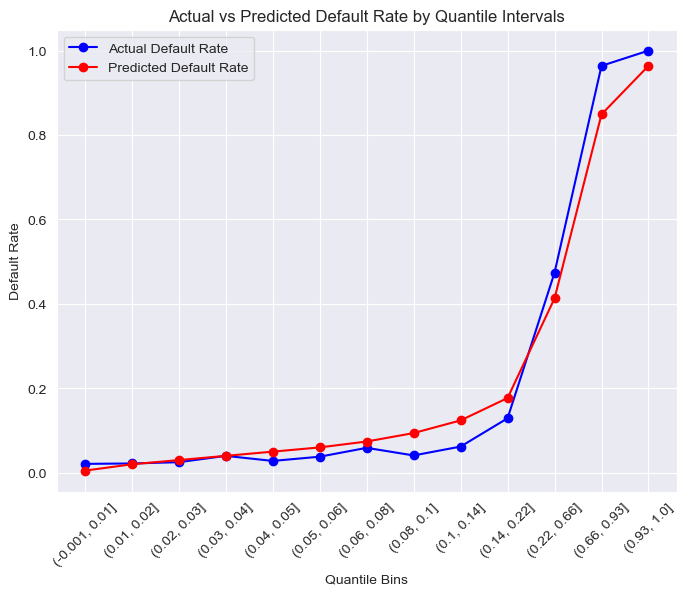

In [11]:
# Plot Actual and Predicted Default Rates
plt.figure(figsize=(8, 6))

# Plot Actual Default Rate
plt.plot(result['Bin'].astype(str), result['Default_Rate'], marker='o', linestyle='-', color='b', label='Actual Default Rate')

# Plot Predicted Default Rate
plt.plot(result['Bin'].astype(str), result['Avearage_PD'], marker='o', linestyle='-', color='r', label='Predicted Default Rate')

# Add labels and title
plt.xlabel('Quantile Bins')
plt.ylabel('Default Rate')
plt.title('Actual vs Predicted Default Rate by Quantile Intervals')
plt.grid(True)

# Show legend and plot
plt.legend()
plt.xticks(rotation=45)  # Rotate bin labels for readability
plt.show()

In [12]:
# Define 10 predefined bins
bin_edges = np.linspace(df['y_prob'].min(), df['y_prob'].max(), 11)  # 10 intervals, 11 edges

# Bin the data into predefined bins
bins = pd.cut(df['y_prob'], bins=bin_edges, include_lowest=True)

# Create a DataFrame with binned data
binned_data = pd.DataFrame({'PD': df['y_prob'], 'Default': df['y_test'], 'Bin': bins})

# Group by bins and calculate statistics
result = binned_data.groupby('Bin').agg(
    Avearage_PD=('PD', 'mean'),
    Default_Rate=('Default', 'mean'),
    Count=('Default', 'count')
).reset_index()

# Round the 'mean' values to 3 decimal places
result['Avearage_PD'] = result['Avearage_PD'].round(3)*100
result['Default_Rate'] = result['Default_Rate'].round(3)*100

In [13]:
result

,Bin,Avearage_PD,Default_Rate,Count
0,"(-0.001, 0.1]",3.0,2.9,6810
1,"(0.1, 0.2]",14.3,8.3,812
2,"(0.2, 0.3]",24.8,19.7,198
3,"(0.3, 0.4]",35.5,30.9,68
4,"(0.4, 0.5]",45.7,60.7,84
5,"(0.5, 0.6]",55.4,81.1,90
6,"(0.6, 0.7]",65.9,79.2,77
7,"(0.7, 0.8]",76.2,89.7,97
8,"(0.8, 0.9]",86.6,98.6,216
9,"(0.9, 1.0]",95.2,100.0,548


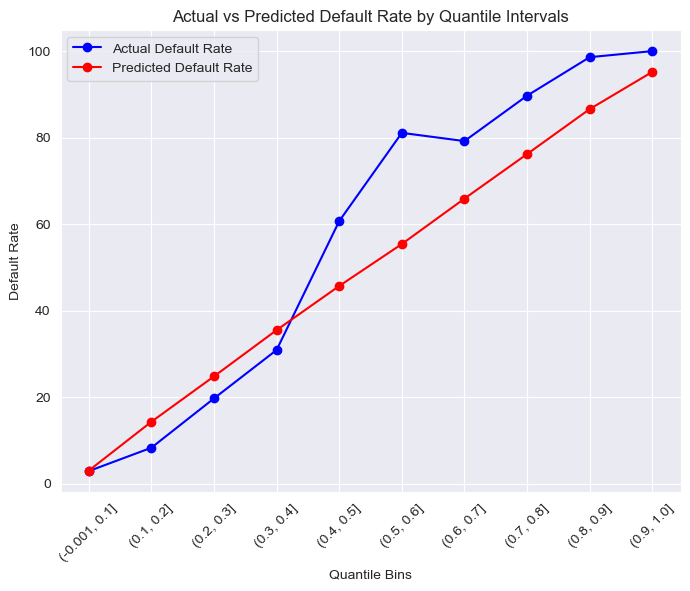

In [14]:
# Plot Actual and Predicted Default Rates
plt.figure(figsize=(8, 6))

# Plot Actual Default Rate
plt.plot(result['Bin'].astype(str), result['Default_Rate'], marker='o', linestyle='-', color='b', label='Actual Default Rate')

# Plot Predicted Default Rate
plt.plot(result['Bin'].astype(str), result['Avearage_PD'], marker='o', linestyle='-', color='r', label='Predicted Default Rate')

# Add labels and title
plt.xlabel('Quantile Bins')
plt.ylabel('Default Rate')
plt.title('Actual vs Predicted Default Rate by Quantile Intervals')
plt.grid(True)

# Show legend and plot
plt.legend()
plt.xticks(rotation=45)  # Rotate bin labels for readability
plt.show()

In [ ]:
Understanding the Data

Bin: Represents a range of probability of default (PD).
Avearage_PD: The estimated probability of default for loans within that bin.
Default_Rate: The actual default rate observed in the bin.
Count: Number of loans falling within that bin.

In [ ]:
Let's assume a risk appetite of a maximum 30% default rate.

Group 1 (Low Risk): Bins (-0.001, 0.1], (0.1, 0.2], (0.2, 0.3] - Default rates are below 30%
Group 2 (Medium Risk): Bins (0.3, 0.4], (0.4, 0.5] - Default rates are between 30% and 60%
Group 3 (High Risk): Bins (0.5, 0.6], (0.6, 0.7], (0.7, 0.8], (0.8, 0.9], (0.9, 1.0] - Default rates are above 60%

In [ ]:
Group 1 (Very Low Risk): Bins (-0.001, 0.1], (0.1, 0.2] - Default rates below 30%
Group 2 (Low Risk): Bin (0.2, 0.3] - Default rates between 30% and 60%
Group 3 (Medium Risk): Bin (0.3, 0.4] - Default rates between 60% and 80%
Group 4 (High Risk): Bins (0.4, 0.5], (0.5, 0.6] - Default rates between 80% and 95%
Group 5 (Very High Risk): Bins (0.6, 0.7], (0.7, 0.8], (0.8, 0.9], (0.9, 1.0] - Default rates above 95%
Note: These thresholds are just an example. You can adjust them based on your risk tolerance and business objectives.
                                                        
                                                        
You might want to consider using percentiles of the default rates to create more data-driven thresholds.

In [ ]:
To convert probabilities of default from the random forest model into a credit scoring system,
we can employ several techniques:

Probability Binning
One common approach is to divide the predicted probabilities into discrete bins or ranges,
each corresponding to a credit score:
- Define probability ranges (e.g., 0-1%, 1-5%, 5-10%, etc.).
- Assign a score to each range (e.g., 800-850 for 0-1%, 750-799 for 1-5%, etc.).
- Map each probability to its corresponding score range.
This method allows for a straightforward interpretation of the probabilities as credit scores.

Logistic Transformation
Another technique involves using a logistic function to transform probabilities into scores:
- Choose a desired score range (e.g., 300-850).
- Apply a logistic function to map probabilities to this range.
- Adjust parameters to fine-tune the distribution of scores.
This approach can provide a smoother transition between probability values and scores.

Score Scaling
You can also directly scale the probabilities to a desired score range:
- Choose your score range (e.g., 300-850).
- Invert the probabilities (higher probability = lower score).
- Scale the inverted probabilities to fit your chosen range.
This method maintains a direct relationship between probabilities and scores.